# Credit Card Fraud Detection: A Complete ML Pipeline

In [44]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier


from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)



In [4]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_style("darkgrid")

RANDOM_STATE = 42


In [12]:
# load data
df = pd.read_csv("data/creditcard.csv")

In [13]:
df.shape

(284807, 31)

In [14]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


Class:
- 0 -> non-fraud
- 1 -> fraud

In [15]:
# basic overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [16]:
# missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [17]:
# quick checks for encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(10))

Time
163152.000    36
64947.000     26
68780.000     25
3767.000      21
3770.000      20
3750.000      19
19912.000     19
140347.000    19
128860.000    19
143083.000    18
Name: count, dtype: int64
V1
2.056     77
1.246     77
2.053     62
1.302     60
2.040     53
2.085     48
1.333     45
1.018     40
1.335     39
-0.303    36
Name: count, dtype: int64
V2
-0.327    77
0.167     77
0.090     62
-0.607    60
-0.147    53
0.393     48
0.389     45
1.037     40
0.331     39
0.447     36
Name: count, dtype: int64
V3
-2.752    77
0.488     77
-1.682    62
-0.682    60
-2.956    53
-4.508    48
-2.166    45
-1.690    40
-2.058    39
-0.496    36
Name: count, dtype: int64
V4
-0.842    77
0.635     77
0.454     62
-1.905    60
-0.578    53
-0.312    48
-0.307    45
1.315     40
-0.346    39
-3.215    36
Name: count, dtype: int64
V5
2.463     77
-0.563    77
0.298     62
1.327     60
2.609     53
3.510     48
2.641     45
1.698     40
2.583     39
2.705     36
Name: count, dtype: int64
V6
3

In [18]:
# duplicate values
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print(f"Number of duplicate rows: {num_duplicates}")

# drop duplicate if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 1081


In [19]:
# target distribution
print(df["Class"].value_counts())
print("-"*50)
print(df["Class"].value_counts(normalize=True) * 100)


Class
0    284315
1       492
Name: count, dtype: int64
--------------------------------------------------
Class
0   99.827
1    0.173
Name: proportion, dtype: float64


This dataset is very unbalanced: fraud cases are much rarer than normal transactions. That means accuracy alone will not tell the full story, so we should look at recall, precision, and class imbalance handling later.

In [ ]:
# imbalance ratio
n_fraud = (df["Class"] == 1).sum()
n_nonfraud = (df["Class"] == 0).sum()
print("\nImbalance ration (non-fraud : fraud) =", round(n_nonfraud / max(n_fraud, 1), 2))


Imbalance ration (non-fraud : fraud) = 577.88


Inference: For every 577 non fraud transaction, there is only 1 fraud transaction

In [21]:
# descriptive stats for key columns

df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000,284807.000
mean,94813.860,88.350
std,47488.146,250.120
min,0.000,0.000
25%,54201.500,5.600
50%,84692.000,22.000
75%,139320.500,77.165
max,172792.000,25691.160


### Data Visualization

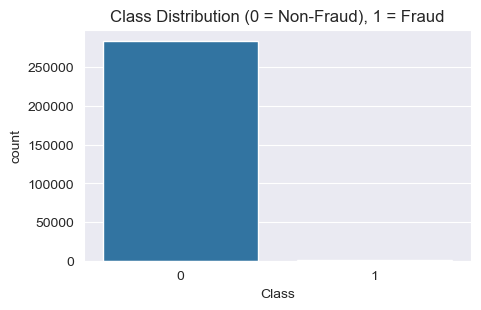

In [34]:
# visualize class imbalance

plt.figure(figsize = (5,3))
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Non-Fraud), 1 = Fraud")
plt.show()

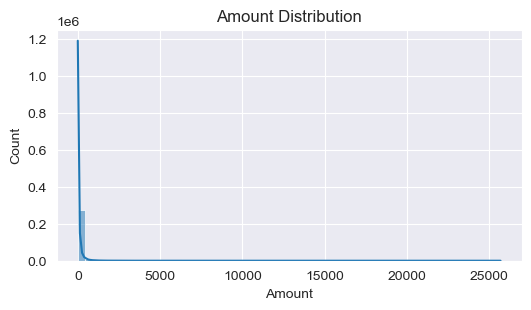

In [23]:
# Amount distribution (raw)
plt.figure(figsize = (6, 3))
sns.histplot(df["Amount"], bins=60, kde=True)
plt.title("Amount Distribution")
plt.show()

The Amount feature is highly skewed, with most transactions concentrated near small values. This is why a log transformation is helpful for making the distribution easier to interpret and model.

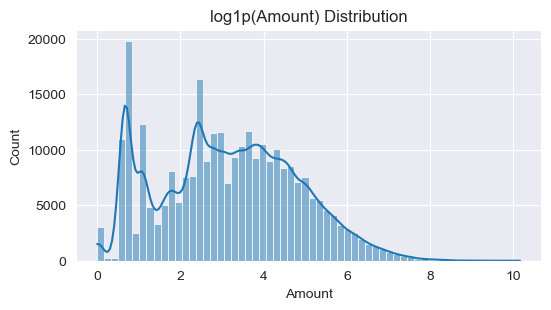

In [24]:
# Amount distribution (raw + log1p)
plt.figure(figsize = (6, 3))
sns.histplot(np.log1p(df["Amount"]), bins =60, kde=True)
plt.title("log1p(Amount) Distribution")
plt.show()

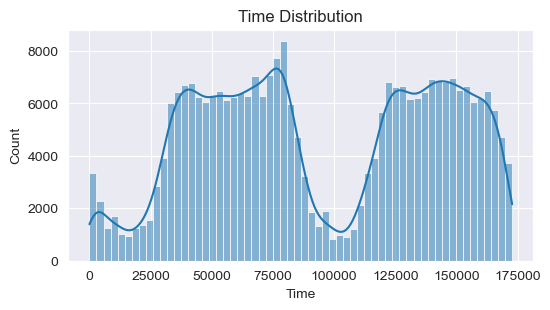

In [25]:
# Time distribution
plt.figure(figsize = (6, 3))
sns.histplot(df["Time"], bins=60, kde=True)
plt.title("Time Distribution")
plt.show()

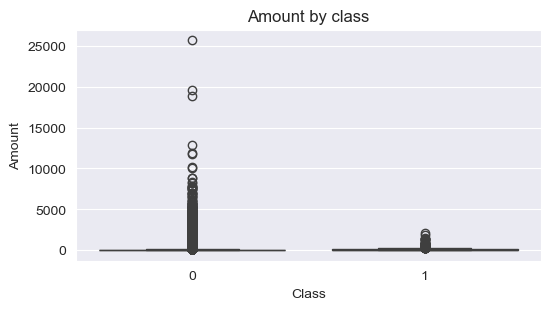

In [27]:
# Amount by class (helps intuition)
plt.figure(figsize=(6, 3))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Amount by class")
plt.show()


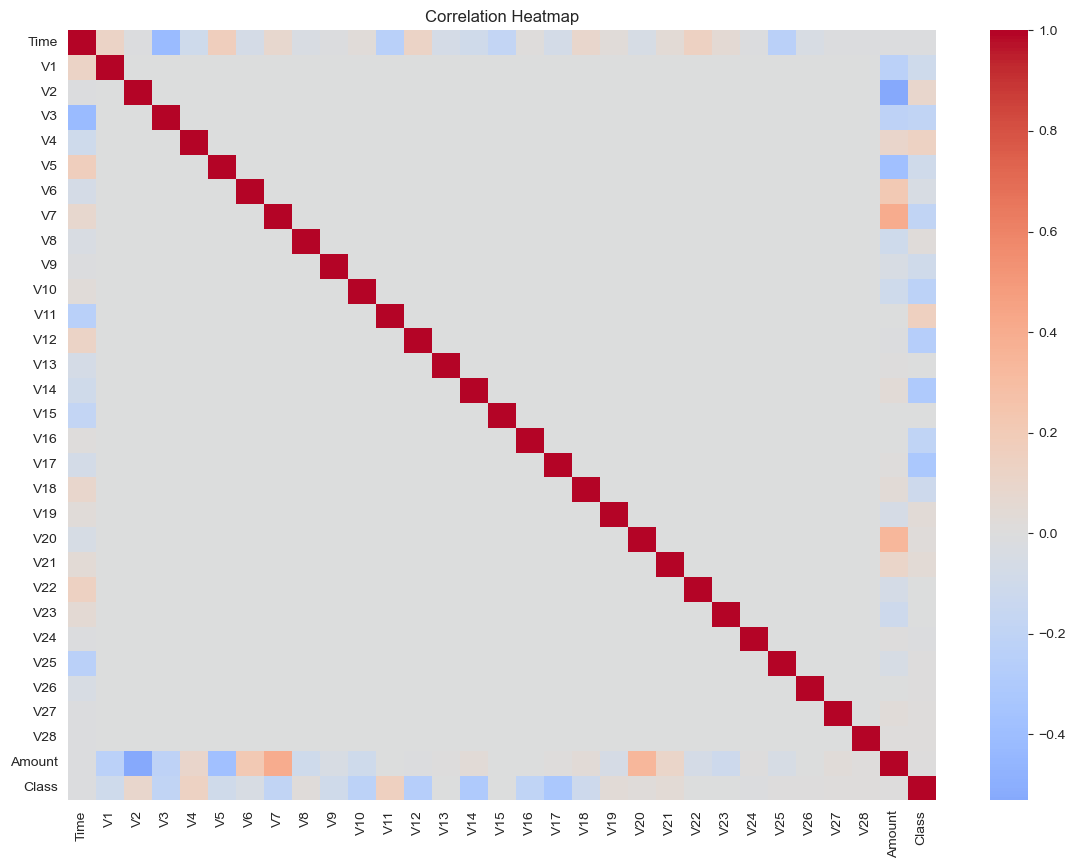

In [28]:
# correltation heatmap 
plt.figure(figsize = (14,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that the features are mostly weakly related to each other, which is expected because many of them are PCA-transformed variables. This means the model will need to learn patterns from combinations of features rather than from one obvious strong signal.

In [33]:
# correlation with target (top signals)
corr_target = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5), corr_target.tail(5)

(Class   1.000
 V11     0.155
 V4      0.133
 V2      0.091
 V21     0.040
 Name: Class, dtype: float64,
 V16   -0.197
 V10   -0.217
 V12   -0.261
 V14   -0.303
 V17   -0.326
 Name: Class, dtype: float64)

This final check shows that no single feature has a strong linear relationship with fraud. That is a useful insight because it tells us the dataset is not easy to solve with simple rules alone, and a stronger model is needed.

### Data Preprocessing

This step prepares the dataset for modeling. We keep the transformed amount value and remove the original Amount column so the model learns from a stable numeric feature.

In [35]:
# Add log1p(Amount) for stability
df["Amount_log1p"] = np.log1p(df["Amount"])

In [36]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log1p'],
      dtype='object')

In [38]:
# separate features and target

X = df.drop(columns=["Class", "Amount"]) # removing Amount as I have Amount_lop1p 
y= df["Class"]


In [40]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [41]:
print("Dataset Shape:", X.shape)
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

Dataset Shape: (284807, 30)
Training Data Shape: (227845, 30)
Test Data Shape: (56962, 30)


Splitting the dataset like this helps us test the model on data it has not seen before. Stratifying keeps the fraud proportion the same in both training and test sets so the comparison is fair.

### Baseline Model

A simple decision tree is used first as a baseline. It gives us a quick sense of how well the raw features perform before we move to stronger models.

In [48]:
base_pipeline = Pipeline(
    [
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [49]:
# train the model
base_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', DecisionTreeClassifier(random_state=42))])

In [56]:
y_base_train_pred = base_pipeline.predict(X_train)
y_base_test_pred = base_pipeline.predict(X_test)

In [62]:
base_train_acc = round(accuracy_score(y_train, y_base_train_pred)*100,2)
base_test_acc = round(accuracy_score(y_test, y_base_test_pred)*100, 2)

In [ ]:
print("Baseline Train Accuracy:", base_train_acc)
print("Baseline Test Accuracy:", base_test_acc)


Baseline Train Accuracy: 100.0
Baseline Test Accuracy: 99.91


In [ ]:
print("Train - Classification Report")
print(classification_report(y_train, y_base_train_pred))


Train - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [68]:
print("Test - Classification Report")
print(classification_report(y_test, y_base_test_pred))

Test - Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



The test report shows how well the model does on the minority fraud class as well as the majority class. In this dataset, precision and recall are more meaningful than raw accuracy because fraud is much rarer.

In [73]:
# average precision score - training data

y_train_prob = base_pipeline.predict_proba(X_train)[:, 1]
print("Training Average precision score:", average_precision_score(y_train, y_train_prob))


Training Average precision score: 1.0


In [75]:
# average precision score - test data

y_test_prob = base_pipeline.predict_proba(X_test)[:, 1]
print("Test Average precision score:", average_precision_score(y_test, y_test_prob))


Test Average precision score: 0.5610321985726947


### Model Selection & Optimization

We compare models using cross-validated Precision-Recall AUC because it focuses on detecting the rare fraud cases and is more useful than accuracy in this problem.

In [79]:
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [81]:
models = {
    "dt_balanced": Pipeline(
        [
            ("model", DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "hgp_balanced": Pipeline(
        [
            ("model", HistGradientBoostingClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    ),
    "rf_balanced": Pipeline(
        [
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced"
            ))
        ]
    )  
}

In [86]:
for name, m in models.items():

    pr_auc_scores = []

    for tr_idx, te_idx, in cv.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        m.fit(X_tr, y_tr)
        pred_prob = m.predict_proba(X_te)[:, 1]

        pr_auc_scores.append(average_precision_score(y_te, pred_prob))
    
    print("Model name:", name)
    print("PR-AUC:", pr_auc_scores)
    print("CV PR-AUC mean:", round(float(np.mean(pr_auc_scores)), 4))



Model name: dt_balanced
PR-AUC: [0.5007266812564823, 0.4830774702828517, 0.5797304220740939, 0.5880053883273093, 0.5312714890725482]
CV PR-AUC mean: 0.5366
Model name: hgp_balanced
PR-AUC: [0.7650653511464124, 0.7426863047121037, 0.6961437658687323, 0.7842427747774444, 0.7429545175433017]
CV PR-AUC mean: 0.7462
Model name: rf_balanced
PR-AUC: [0.8423466244325414, 0.8148715466307828, 0.830418381185712, 0.8821778726675099, 0.8271070867780583]
CV PR-AUC mean: 0.8394


The Random Forest model performs best according to the cross-validation score. This means it is likely the strongest choice here, but further tuning and testing can make it even better.